# Extended Data Analysis Assignment
## Module 503: _Applications of Data Science and Statistics_
## Student full Name: _Keladome Maturin Geoffroy Dato_
## Student ID: _720084978_
## Academic year: _2024/2025_
## University: _The University of Exeter_

## _Declaration_

AI-supported/AI-integrated use is permitted in this assessment. I acknowledge the following uses of GenAI tools in this assessment:

[$\checkmark$]          I have used GenAI tools for developing ideas.

[ $\checkmark$ ]        I have used GenAI tools to assist with research or gathering information.

[ $\checkmark$ ]        I have used GenAI tools to help me understand key theories and concepts.

[ $\checkmark$ ]        I have used GenAI tools to identify trends and themes as part of my data analysis.

[ $\checkmark$ ]        I have used GenAI tools to suggest a plan or structure for my assessment.

[ $\checkmark$ ]        I have used GenAI tools to give me feedback on a draft.

[ $\checkmark$ ]        I have used GenAI tool to generate images, figures or diagrams.

[ $\checkmark$ ]        I have used GenAI tools to proofread and correct grammar or spelling errors.

[ $\checkmark$ ]        I have used GenAI tools to generate citations or references.

[ $\checkmark$ ]        I have not used any GenAI tools in preparing this assessment.

I declare that I have referenced use of GenAI outputs within my assessment in line with the University referencing guidelines.

# Introduction
The assignment is to assess  our knowledge and understanding through the Applications of Data Science and Statistics module.
This assignment consists in three sections as follow:
1. Analyse the gene expression dataset using Principal Component Analysis (PCA) and logistic regression,
2. Model Sea level change by building a regression model to explain the changes in mean sea level in three locations over time,
3. Perform clustering on power data recordings at substations in order to see whether there are groups that have similar demand profiles.

## Libraries needed in these datasets analysis include:

In [1]:
# Necessary libraries for plotting
from plotnine import * ## needed to 
import seaborn as sns  
import matplotlib.pyplot as plt 

# libraries for data importation and manipulation
import numpy as np  
import pandas as pd  

## libraries for dimensionality reduction
from sklearn import decomposition ## needed module to perform PCA
from sklearn.preprocessing import StandardScaler ## needed to 
import torch ## needed to 
import torch.nn as nn ## needed to 
from torchvision import transforms # needed for data processing

# libraries for clustering
from sklearn.cluster import AgglomerativeClustering ## needed to 
from scipy.cluster.hierarchy import dendrogram, linkage ## needed to perform and display the dendrogram
from sklearn.metrics import silhouette_samples, silhouette_score ## needed for clusters's evaluation
from scipy.spatial.distance import pdist, squareform ## needed to perform distance metric
from sklearn.cluster import KMeans ## needed to perform KMeans clustering
from sklearn_extra.cluster import KMedoids ## needed to perform other metrics except euclidian distance 


# Libraries for linear and logistic regressions 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error

# Section A: Analysis of the gene expression dataset

In [81]:
# loading the gene dataset
gene = pd.read_csv('C:/Users/dageo/MTHM503/Assignment/gene_file.csv')

In [6]:
gene.keys()

Index(['samples', 'type', '1007_s_at', '1053_at', '117_at', '121_at',
       '1255_g_at', '1294_at', '1316_at', '1320_at',
       ...
       'AFFX-r2-Ec-bioD-3_at', 'AFFX-r2-Ec-bioD-5_at', 'AFFX-r2-P1-cre-3_at',
       'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at', 'AFFX-ThrX-5_at',
       'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at',
       'AFFX-TrpnX-M_at'],
      dtype='object', length=54677)

In [7]:
gene.head(n=2)

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,834,ependymoma,12.498150,7.604868,6.880934,9.027128,4.176175,7.224920,6.085942,6.835999,...,9.979005,9.92647,12.719785,12.777792,5.403657,4.870548,4.047380,3.721936,4.516434,4.749940
1,835,ependymoma,13.067436,7.998090,7.209076,9.723322,4.826126,7.539381,6.250962,8.012549,...,11.924749,11.21593,13.605662,13.401342,5.224555,4.895315,3.786437,3.564481,4.430891,4.491416


## 1- Split of the df_gene dataset into training (80%) and testing (20%) sets and standardization
Data should be scaled to ensure that all dataset features contribute equally to the model and improve its performance. Scaling is especially important in Data Science particularly in machine learning algorithms that are sensitive to the magnitude of feature values, such as those relying on distance metrics (K-Means clustering, k-nearest neighbours, support vector machines,...etc) or gradient-based optimization (linear regression, logistic regression, neural networks,...etc).

When features in a dataset have different ranges or units, the algorithms might disproportionately focus on features with larger scales, leading to biased results or slower convergence during training. Scaling standardizes the features by putting them on the same scale, either by normalizing them to a range or standardizing them to have a mean of 0 and a standard deviation of 1.

This preprocessing step is essential for models like PCA, where variance plays a role, and for distance-based models where feature magnitudes impact calculations directly. However, it may not be necessary for models like decision trees or random forests, which are scale-invariant.

In [82]:
# selection of gene expression measurements 
df_gene = gene.drop(columns=['samples','type'])
# class labels
y = gene.type

In [83]:
# Scale of the dataset
scale = StandardScaler()
df_gene_scaled = scale.fit_transform(df_gene)

In [84]:
# Split of the df_gene dataset into training (80%) and testing (20%) sets
X_gene_train, X_gene_test, y_gene_train, y_gene_test = train_test_split(df_gene_scaled,y,test_size=0.2,random_state=42,train_size=0.8,stratify=y)

In [699]:
X_gene_train.shape, X_gene_test.shape, y_gene_train.shape, y_gene_test.shape,df_gene.shape

((93, 54675), (24, 54675), (93,), (24,), (117, 54675))

## 2. The dimensionality reduction using PCA

Now let's perform the Principle Component Ananlysis. PCA performance requires `decomposition` module of `scikit-learn` which was already called earlier using `decomposition.PCA`.

## _Principle Component Ananlysis considering all the principal components_

In [168]:
pca = decomposition.PCA()
X_train_pca = pca.fit_transform(X_gene_train)

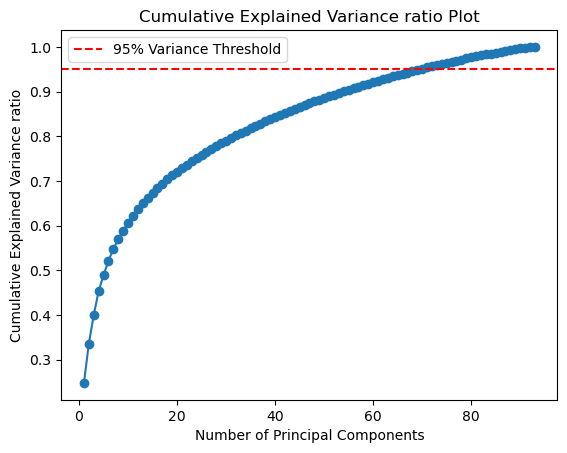

In [169]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the cumulative explained variance
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance Threshold")
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance ratio')
plt.title('Cumulative Explained Variance ratio Plot')
plt.legend()
plt.show()

In [170]:
# Find the number of components that explain 95% variance
n_components_95 = np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.95) + 1  # Adding 1 as index starts from 0
print(f"The optimal number of components to retain that explain 95% variance of the dataset is: {n_components_95}")

The optimal number of components to retain that explain 95% variance of the dataset is: 70


The optimal number of components to retain is chosen by taking the first principal components which the cumulative explained variance ratio is at least 95%. 
In this case, this number is 70.

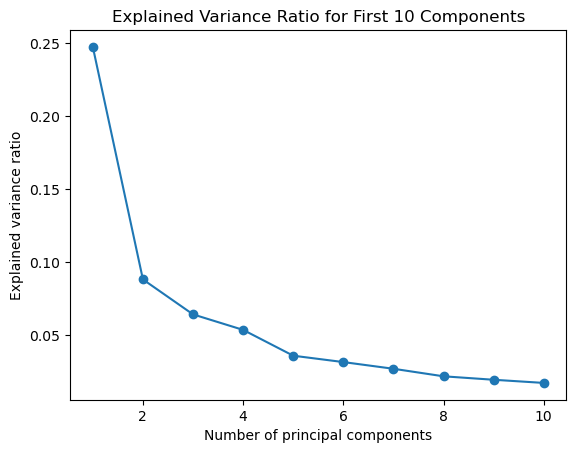

In [171]:
# How to choose optimal number of principal components
N = 10  # Number of components to visualize
components = np.arange(1, N + 1)
plt.plot(components, pca.explained_variance_ratio_[:N], 'o', linestyle="-")
plt.xlabel("Number of principal components")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance Ratio for First 10 Components")
plt.show()

The elbow graphic shows that three principal components explain 95 percent of the total of the variance in the gene expression data.
The visualisation of the cancer gene expression through a scatter plot will demonstrate how well the transformed numbers separate the different type groups of cancer.

## _3.1-Visualisation of the results of dimensionality reduction after performing PCA_
To do this, we decide to choose the first two principal components from the transformed dataset.

In [172]:
# dataset transformation where each data point is represented in terms of the principal components rather than the original features. 
# The new dataset has fewer dimensions meaning the 70
y_1 = pca.transform(df_gene_scaled) 
df_pca = pd.DataFrame(y_1[:, 0:2], columns = ["PC1", "PC2"])
df_pca["type"] = gene.type

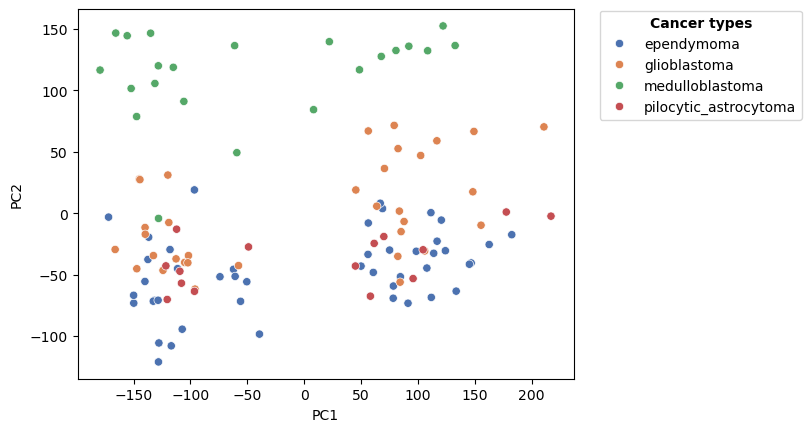

In [173]:
sns.scatterplot(x = "PC1", y = "PC2", hue = "type", data = df_pca, palette = "deep")
# Adjust the legend placement
legend = plt.legend(title='Cancer types',bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.1)
# Underline the title by manually modifying it
title = legend.get_title()
title.set_fontsize(10)
title.set_fontweight('bold')
plt.show()

The scatter plot demonstrates that only the cancer type `medulloblastoma` has very few overlapping and is completely separate from others.

## _Principle Component Ananlysis considering the optimal principal components_

In [174]:
pca_2 = decomposition.PCA(n_components=70)
X_train_pca_2 = pca_2.fit_transform(X_gene_train)

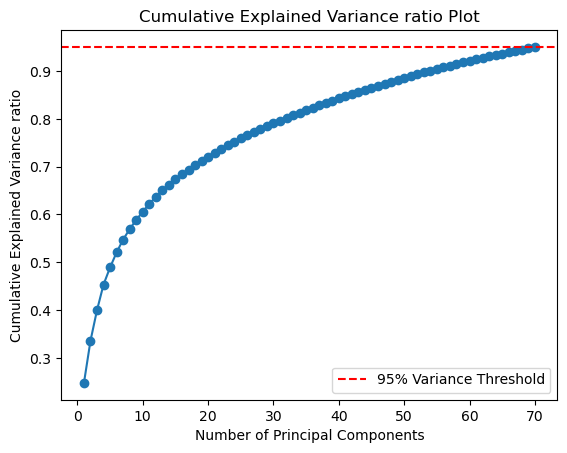

In [175]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca_2.explained_variance_ratio_)

# Plot the cumulative explained variance
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance Threshold")
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance ratio')
plt.title('Cumulative Explained Variance ratio Plot')
plt.legend()
plt.show()

In [176]:
# Find the number of components that explain 95% variance
n_components_95 = np.argmax(pca_2.explained_variance_ratio_.cumsum() >= 0.95) + 1  # Adding 1 as index starts from 0
print(f"The optimal number of components to retain that explain 95% variance of the dataset is: {n_components_95}")

The optimal number of components to retain that explain 95% variance of the dataset is: 70


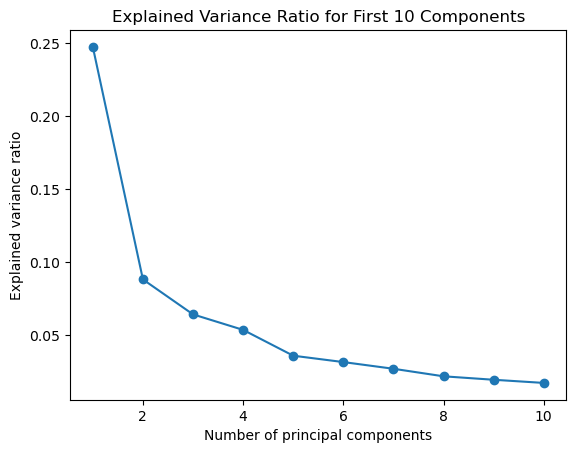

In [177]:
# How to choose optimal number of principal components
N = 10  # Number of components to visualize
components = np.arange(1, N + 1)
plt.plot(components, pca_2.explained_variance_ratio_[:N], 'o', linestyle="-")
plt.xlabel("Number of principal components")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance Ratio for First 10 Components")
plt.show()

## _3.2-Visualisation of the results of dimensionality reduction after performing PCA_
To do this, we decide to choose the first two principal components from the transformed dataset.

In [178]:
# dataset transformation where each data point is represented in terms of the principal components rather than the original features. 
# The new dataset has fewer dimensions meaning two
y_2 = pca_2.transform(df_gene_scaled) 
df_pca = pd.DataFrame(y_2[:, 0:2], columns = ["PC1", "PC2"])
df_pca["type"] = gene.type

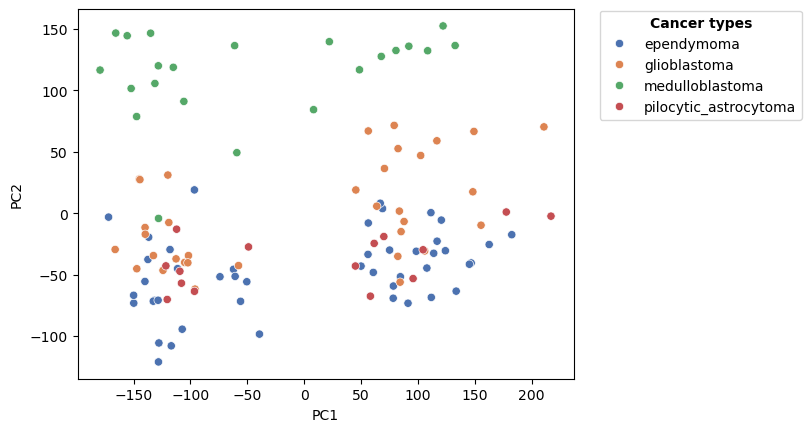

In [179]:
sns.scatterplot(x = "PC1", y = "PC2", hue = "type", data = df_pca, palette = "deep")
# Adjust the legend placement
legend = plt.legend(title='Cancer types',bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.1)
# Underline the title by manually modifying it
title = legend.get_title()
title.set_fontsize(10)
title.set_fontweight('bold')
plt.show()

## Summary of the dimensionality reduction

As we can see, the scatterplot demonstrates that there is no differences while performing the principal components analysis specifying the number of components or not.
    In brief, without or with the optimal number of components, the majority of variance is captured with two components. Retaining additional components could add more details to the data structure but does not affect the first two one. In the scatterplot graphic we can notice that:
    
- The `medulloblastoma` group is well separated along the second axe indicating that this cancer type has distinct features that differentiate it from the others. This implies that `medulloblastoma` has the most distinguishable features among the cancer types.
- The `glioblastoma` group shows moderate separation along the first and second components but overlapping to other groups, suggesting common shared features with `ependymoma`, `pilocytic astrocytoma`.
- The `ependymoma` group is widely spread and overlaps highly with other cancer types, particularly `pilocytic astrocytoma`.
- The `pilocytic astrocytoma` group appears as a small cluster primarily overlapping with `pilocytic astrocytoma` group.

## 4. Logistic regression modelling using the PCA-transformed
Logistic regression is part of supervise learning models used to classify group of targets.

In [183]:
# import and initialise logistic regression, need to increase 
# max_iter to ensure convergence
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(max_iter = 1000)
# initialise, fit, and transform gene dataset with PCA (2 components)
pca_2 = decomposition.PCA(n_components=70)
X_train_pca_2 = pca_2.fit_transform(X_gene_train)
X_test_pca_2 = pca_2.transform(X_gene_test)

# Fit the Logistic Regression Model
logit = LogisticRegression(multi_class='multinomial',random_state=42, max_iter=1000)
logit.fit(X_train_pca_2, y_gene_train)


#y_fit = logreg_digits.predict(X)

LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [184]:
logit.coef_

array([[ 2.07929999e-03, -4.54300985e-02,  6.17520996e-02,
        -6.42538560e-02, -5.63602999e-03,  2.20394172e-03,
        -1.33392113e-02,  5.79557639e-03,  6.71776196e-03,
         1.66237589e-02, -9.59907665e-03, -3.21539986e-04,
        -1.20713270e-02,  1.83021663e-02, -1.02760839e-02,
        -5.55961599e-04, -8.19974502e-03, -8.37112864e-03,
         6.04295701e-04, -4.60939538e-03,  1.50062775e-02,
        -1.55063217e-02,  1.76262359e-02,  1.56371342e-03,
         6.03855898e-03,  3.09709657e-03,  9.39830674e-03,
        -9.78233089e-03,  4.69419607e-03, -4.74010745e-04,
        -2.34169566e-03, -2.96096600e-03,  9.53919870e-03,
         4.30943001e-03, -3.31058922e-03,  1.15310586e-02,
         1.47715931e-03,  6.82868086e-03, -4.72188395e-03,
         7.63711342e-03, -1.37733972e-03, -6.48752990e-03,
         5.02521567e-03,  4.59464932e-04, -7.28133514e-03,
        -4.21607845e-03,  3.74029592e-03, -5.03522448e-03,
         1.27341210e-03,  1.29257744e-02,  3.58464067e-0

In [193]:
# Predict on PCA-transformed test data
y_pred = logit.predict(X_test_pca_2)

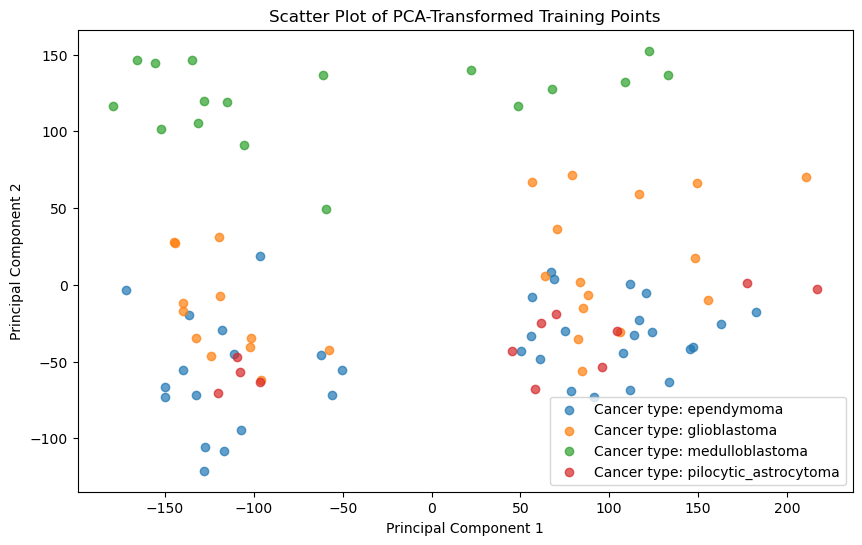

In [189]:
# Scatter plot
plt.figure(figsize=(10, 6))
for label in np.unique(y_gene_train):
    plt.scatter(
        X_train_pca_2[y_gene_train == label, 0],  # PCA Component 1
        X_train_pca_2[y_gene_train == label, 1],  # PCA Component 2
        label=f'Cancer type: {label}',
        alpha=0.7
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of PCA-Transformed Training Points')
plt.legend()
plt.show()

In [192]:
np.mean(y_gene_test == y_pred)

0.875

In [194]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_gene_test, y_pred))
print("\nClassification Report:\n", classification_report(y_gene_test, y_pred))

Accuracy: 0.875

Classification Report:
                        precision    recall  f1-score   support

           ependymoma       0.89      0.89      0.89         9
         glioblastoma       0.88      1.00      0.93         7
      medulloblastoma       1.00      0.80      0.89         5
pilocytic_astrocytoma       0.67      0.67      0.67         3

             accuracy                           0.88        24
            macro avg       0.86      0.84      0.84        24
         weighted avg       0.88      0.88      0.87        24



## _Interpretation of the classification report_
There is a high performance on Glioblastoma. The model performs exceptionally well on `glioblastoma`, with perfect recall (no false negatives) and a good precision score. The F1-score of 0.93 reflects this good balance. The performance on `ependymoma` is also strong, with good precision and excellent recall, resulting in a balanced F1-score of 0.89. The model is very precise for medulloblastoma, meaning there are no false positives, but recall is slightly lower (80%) with the F1-score of 0.89 making it balanced. There is moderate performance of the model on `pilocytic astrocytoma`, with both precision and recall at 0.67, indicating some challenges in classifying this class correctly.

Overall, The most accurately predicted cancer type in the model is `Medulloblastoma`. This suggests that the model is particularly effective at identifying medulloblastoma instances, making it the most accurately predicted cancer type in the classification report compared to other class.

# Section B: Sea level change modelling

In [229]:
# loading the sea levelchange dataset
sea = pd.read_csv('C:/Users/dageo/MTHM503/Assignment/sealevel.csv')

In [233]:
sea.head(n=5)

,date,Location,MeanSeaLevel,Months
0,2000-01-01,Bering Sea,-37.856667,1
1,2000-01-01,Mediterranean,-35.506667,1
2,2000-01-01,World,2.513333,1
3,2000-02-01,Bering Sea,-55.023333,2
4,2000-02-01,Mediterranean,-39.473333,2


In [276]:
# convert date to dateime format
sea['date'] = pd.to_datetime(sea['date'])
sea['year'] = sea['date'].dt.year
# rename Change in Mean Sea Level (mm) column to MeanSeaLevel
sea = sea.rename(columns={'Change in Mean Sea Level (mm)': 'MeanSeaLevel'})

# creation of Months columns
sea['Months'] = sea['date'].dt.month
#sea['Months'] = (sea['date'] - pd.Timestamp('2000-01-01')) / pd.Timedelta(days=30) 
#sea['Months'] = sea['Months'].astype(int)  # Convert to integer for whole months

In [700]:
sea.head(2)

,date,Location,MeanSeaLevel,Months,year
0,2000-01-01,Bering Sea,-37.856667,1,2000
1,2000-01-01,Mediterranean,-35.506667,1,2000


## Exploratory Analysis

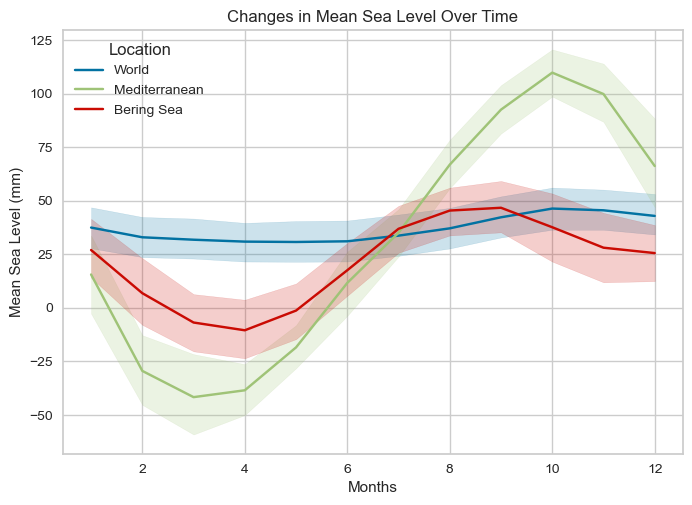

In [464]:
# Exploratory visualization
sns.lineplot(data=sea, x="Months", y="MeanSeaLevel", hue="Location")
plt.title("Changes in Mean Sea Level Over Time")
plt.ylabel("Mean Sea Level (mm)")
plt.xlabel("Months")
plt.show()

From the graph above, it follows that the `World mean sea level` remains relatively stable throughout the year, with minor fluctuations. There is a small upward trend approximatively 50 mm around May up to October before stabilizing again in later months. This shows much less seasonal variation compared to regional locations and reflects the combined averaging of sea level changes across diverse global regions, where regional extremes like the Bering Sea and Mediterranean are balanced out. Meanwhile, the `Mediterranean Sea` shows strong seasonal variability. The sea level decreases dramatically in the first three months, reaching its lowest point around March (approximatively -50 mm) then increases sharpely from April to October where it reaches its peak close to 120 mm and decreases again in the last months. Similarly, in the same time, the `Bering` one experiences a sharp seasonal fluctuation. It decreases significantly during the first four months, reaching its lowest point in April (0 mm) and steadily increases and peaks around August (close to 50 mm). The trend begins to decline slowly and stabilises at a lower level (25 mm) by December.

## Linear regression modelling

In [307]:
# Set 'World' as the first level in the category
sea['Location'] = pd.Categorical(sea['Location'], categories=['World', 'Mediterranean', 'Bering Sea'], ordered=True)

encoder = OneHotEncoder(sparse_output=False, drop='first')  # to drop the reference level ('World') for reduced collinearity
encoded_columns = encoder.fit_transform(sea[['Location']])
df_sea_encoded = pd.DataFrame(encoded_columns, columns=['Location_Mediterranean', 'Location_BeringSea']) # convert to dataframe
df_sea = pd.concat([sea, df_sea_encoded], axis=1) # combine with the original dataframe

In [715]:
# Add interaction terms (degree=2 generates all pairwise interactions)
from sklearn.preprocessing import PolynomialFeatures # needed to include interaction term
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
# Define features and response
X = df_sea[['Months', 'Location_Mediterranean','Location_BeringSea']]  
y = df_sea['MeanSeaLevel']
X_interaction = poly.fit_transform(X) # Includes interaction term

In [704]:
df_sea.head(n=2)

,date,Location,MeanSeaLevel,Months,year,Location_Mediterranean,Location_BeringSea,y_pred,Type
0,2000-01-01,Bering Sea,-37.856667,1,2000,0.0,0.0,3.462347,Predicted
1,2000-01-01,Mediterranean,-35.506667,1,2000,1.0,0.0,-39.983366,Predicted


In [711]:
lm = LinearRegression().fit(X_interaction,y)

In [712]:
lm.coef_

array([  3.22184839, -53.12727162,  28.74090599,   9.68155877,
        -1.9973102 ,   0.        ])

In [713]:
lm.intercept_

0.2404984891317703

`MeanSeaLevel` = $\beta_0$ + $\beta_1$(`Months`) + $\beta_2$(`Location_Mediterranean`) + $\beta_3$(`Location_BeringSea`) + $\beta_4$(`Months` $\times$ `Location_Mediterranean`) + $\beta_5$(`Months`$\times$`Location_BeringSea`)

- Coefficients

$\beta_0 = 0.2405$

$\beta_1 = 3.2218$

$\beta_2 = -53.1273$

$\beta_3 = 28.7409$

$\beta_4 = 9.6816$

$\beta_5 = -1.9973$

- Intercepts and Slopes Calculation
 
world_intercept $ = \beta_0 = 0.2405$

world_slope $ = \beta_1 = 3.2218$

Months $\times$ Mediterranean_intercept $ = \beta_0 + \beta_2 = 0.2405 + (−53.1273) = −52.8868$

Months $\times$ Mediterranean_slope $ = \beta_1 + \beta_4 = 3.2218 + 9.6816 = 12.9034$

Months $\times$ Beringsea_intercept $ = \beta_0 + \beta_3 = 0.2405 + 28.7409 = 28.9814$

Months $\times$ Beringsea_slope $ = \beta_1 + \beta_5 = 3.2218 + (−1.9973) = 1.2245$

The final model equation is :

`MeanSeaLevel` $=$ 0.2405 + 3.2218(`Months`) −53.1273(`Location_Mediterranean`) + 28.7409(`Location_BeringSea`) + 9.6816(`Months` $\times$ `Location_Mediterranean`) −1.9973(`Months`$\times$`Location_BeringSea`)

Basically, compared to the global mean sea level, the mean sea level reduces by -53.13 mm in the `Mediterranean` while it increases by 28.74 mm in the `Bering sea`.In addition, the `World` mean sea level starts at 0.24 mm and increases by 3.22 mm for each additional unit of months while the `Mediterranean` starts at -52.89 mm and increases by 12.90 mm per month. Meanwhile, the `Bering Sea` Starts at 28.98 mm and increases by only 1.22 mm per month. 


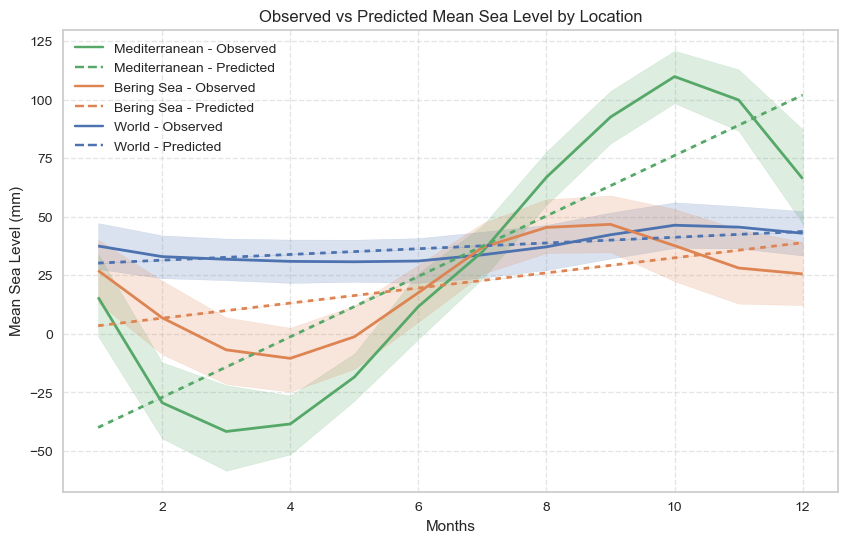

In [716]:
# Add predictions to the DataFrame
df_sea['y_pred'] = lm.predict(X_interaction)

import matplotlib.lines as mlines

plt.figure(figsize=(10, 6))

# Define the 'deep' palette with 3 colors and reorder them: Mediterranean = green, Bering Sea = red, World = blue
palette = sns.color_palette("deep", n_colors=3)
palette = [palette[0], palette[2], palette[1]]  # Reordering the colors to: Blue (World), Green (Mediterranean), Red (Bering Sea)

# Observed Mean Sea Level (solid lines)
sns.lineplot(data=df_sea, x='Months', y='MeanSeaLevel',
             hue='Location', style='Location',
             dashes=[(1, 0), (1, 0), (1, 0)],  # Solid lines for all locations
             palette=palette, linewidth=2, legend=False)

# Predicted Mean Sea Level (dashed lines)
sns.lineplot(data=df_sea, x='Months', y='y_pred',
             hue='Location', style='Location',
             dashes=[(2, 2), (2, 2), (2, 2)],  # Dashed lines for all locations
             palette=palette, linewidth=2, legend=False)

# Custom legend with the same colors used in the plot
legend_elements = [
    mlines.Line2D([], [], color=palette[1], linestyle='-', label='Mediterranean - Observed'),
    mlines.Line2D([], [], color=palette[1], linestyle='--', label='Mediterranean - Predicted'),
    mlines.Line2D([], [], color=palette[2], linestyle='-', label='Bering Sea - Observed'),
    mlines.Line2D([], [], color=palette[2], linestyle='--', label='Bering Sea - Predicted'),
    mlines.Line2D([], [], color=palette[0], linestyle='-', label='World - Observed'),
    mlines.Line2D([], [], color=palette[0], linestyle='--', label='World - Predicted')
]

# Add custom legend to the plot
plt.legend(handles=legend_elements, loc='upper left')

plt.title("Observed vs Predicted Mean Sea Level by Location")
plt.xlabel("Months")
plt.ylabel("Mean Sea Level (mm)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


From the predictive graph of the mean sea level by location, it appears that only the observed world mean sea level fits best the prediction compared to others. The model does not fully capture the non-linear seasonal patterns in the Mediterranean as well as in the Bering sea this, due to the high seasonal fluctuation of the mean sea level through these regional locations.

- ## Model evaluation

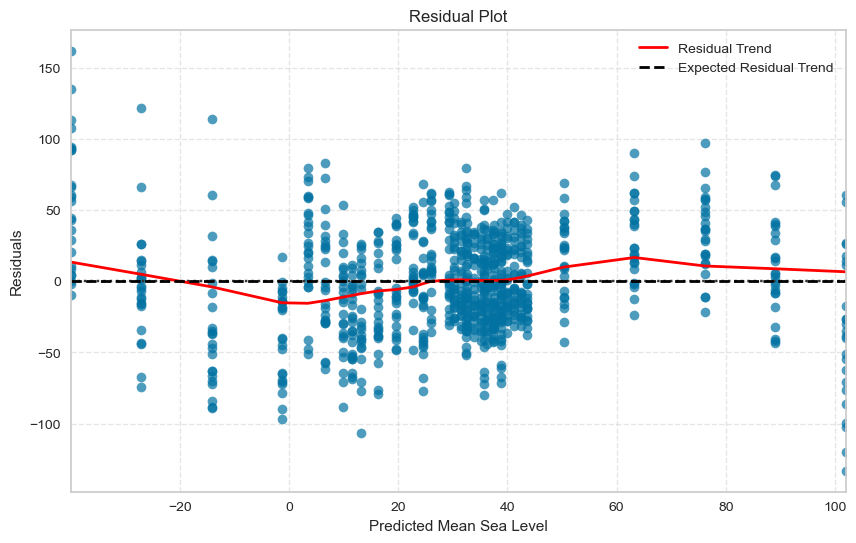

In [452]:
# Residuals plot

residuals = y - y_pred  # Residuals are the difference between actual and predicted values

plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 2}, 
              scatter_kws={'alpha': 0.7}, 
              label="")  

# Add the smoothed red line to legend
plt.plot([], [], color='red', lw=2, label="Residual Trend")

# Add the zero line to legend
plt.axhline(0, linestyle='--', color='black', lw=2, label="Expected Residual Trend")

# Adding titles, labels, and grid
plt.title("Residual Plot")
plt.xlabel("Predicted Mean Sea Level")
plt.ylabel("Residuals")
plt.grid(True, linestyle='--', alpha=0.5)

# Add the legend
plt.legend( loc="best")

plt.show()

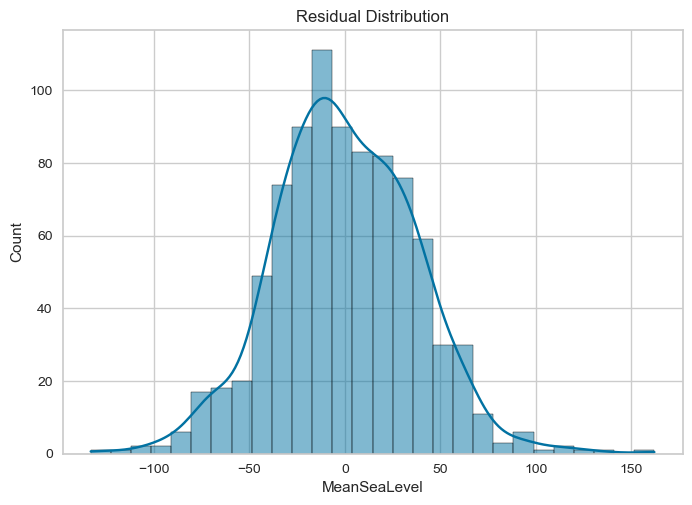

In [463]:
# Residual distribution
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [409]:
R2 = lm.score(X_interaction,y)
R2

0.3531029210836689

The residuals graph and the histogram demonstrate that the residuals approximate the normal distribution with minimal variation indicating that the model capture the majority information on the dataset. But the $R^2$ is 0.35, very low making the model doubtful. An additional covariates to the model could adjust it and increase the $R^2$.

# Section C: Power demand clustering

In [483]:
# loading of the power data recordings at substations
stations = pd.read_csv('C:/Users/dageo/MTHM503/Assignment/January_2013.csv')
stations.shape

(15095, 146)

In [508]:
stations.head(n=2)

,Date,Substation,00:00,00:10,00:20,00:30,00:40,00:50,01:00,01:10,...,22:20,22:30,22:40,22:50,23:00,23:10,23:20,23:30,23:40,23:50
0,2013-01-03,511016,256.704,259.392,264.192,262.752,247.68,238.656,243.168,230.208,...,326.016,331.200,317.37600,305.568,290.40000,295.296,292.896,288.864,273.216,259.776
1,2013-01-03,511029,96.000,111.168,115.968,98.976,123.36,128.352,129.696,125.952,...,100.752,97.008,99.64799,98.544,98.01601,101.472,97.056,97.584,105.696,104.640


In [485]:
stations_ID.keys()

Index(['Date', 'Substation'], dtype='object')

## 1- Data-processing

 - (i) Division of each 10 minute interval record by maximum value in the row

In [502]:
# Division of the power recorded in each 10 minute interval by its corresponding daily maximum (i.e. the maximum value in the row)

# exclude date and substation column
stations_ID = stations[['Date','Substation']]

stations_norm = stations.drop(columns=['Date','Substation'])

## Normalize each row's interval values by its daily maximum
stations_norm = stations_norm.div(stations_norm.max(axis=1),axis=0)

# combine the datasets into one
df_stations = pd.concat([stations_ID, stations_norm], axis=1)

df_stations.head(n=2)

,Date,Substation,00:00,00:10,00:20,00:30,00:40,00:50,01:00,01:10,...,22:20,22:30,22:40,22:50,23:00,23:10,23:20,23:30,23:40,23:50
0,2013-01-03,511016,0.596742,0.602990,0.614149,0.610801,0.575764,0.554787,0.565276,0.535148,...,0.757867,0.769917,0.737782,0.710333,0.675073,0.686454,0.680875,0.671502,0.635126,0.603883
1,2013-01-03,511029,0.624220,0.722846,0.754057,0.643571,0.802122,0.834582,0.843321,0.818976,...,0.655119,0.630774,0.647940,0.640762,0.637328,0.659800,0.631086,0.634519,0.687266,0.680400


- (ii) Remove of observation obtained during the weekends

In [495]:
# convert date to datetime
df_stations['Date'] = pd.to_datetime(df_stations['Date'])
df_stations = df_stations[df_stations['Date'].dt.weekday < 5]
df_stations.shape

(10912, 146)

- (iii) calculate the average daily power demand profiles

In [506]:
df_normalised = df_stations.drop(columns=['Substation', 'Date'])

# Calculate the row-wise mean for each substation
df_stations_avg = df_stations.groupby('Substation')[df_normalised.columns].mean()
df_stations_avg.head(n=2)

,00:00,00:10,00:20,00:30,00:40,00:50,01:00,01:10,01:20,01:30,...,22:20,22:30,22:40,22:50,23:00,23:10,23:20,23:30,23:40,23:50
Substation,,,,,,,,,,,,,,,,,,,,,
511016,0.621594,0.624900,0.610020,0.599206,0.590245,0.578324,0.566139,0.553497,0.545042,0.536269,...,0.776125,0.763019,0.744475,0.739289,0.724696,0.709170,0.687730,0.670186,0.647415,0.633929
511029,0.567744,0.641737,0.675054,0.701639,0.762181,0.749306,0.733642,0.716187,0.707857,0.697664,...,0.738899,0.713231,0.681916,0.671688,0.650649,0.637245,0.622475,0.606873,0.603484,0.603634


## 2- Hierarchical clustering

- (i) Choice of the Distance matrix 

In [628]:
# Calcul of the distance matrix using Correlation distance and convert it into squarform
distance_matrix = pdist(df_stations_avg.values, metric="euclidean")

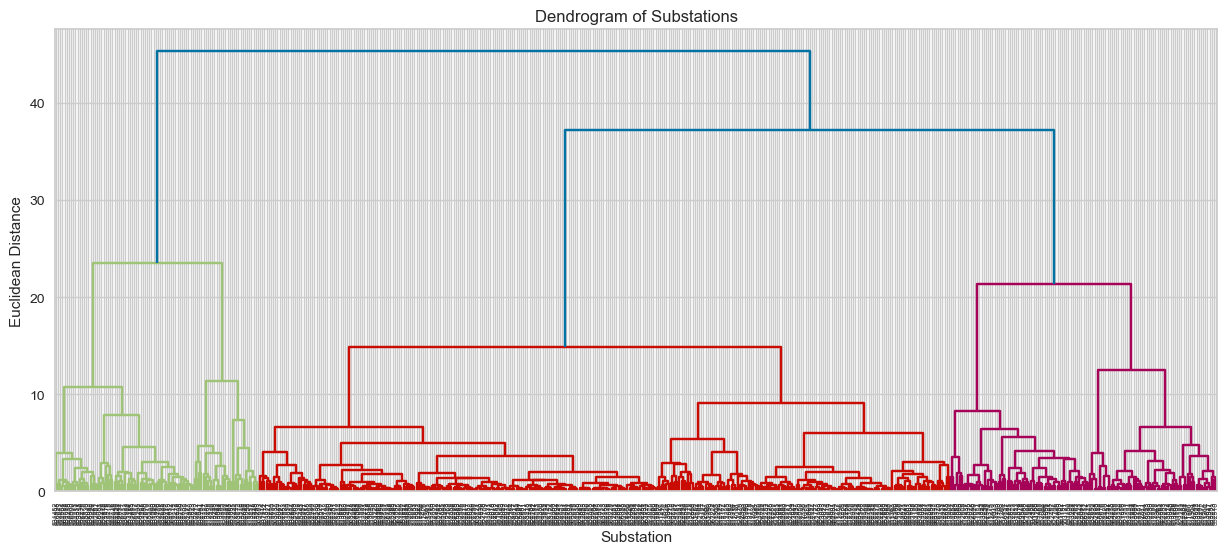

In [645]:
import scipy.cluster.hierarchy as sch

# hierarchical clustering using Ward's linkage
linkage_matrix = sch.linkage(distance_matrix, method='ward')

# Visualize the dendrogram
plt.figure(figsize=(15, 6))
dendrogram = sch.dendrogram(linkage_matrix, labels=df_stations_avg.index, leaf_rotation=90,orientation='top')
plt.title("Dendrogram of Substations")
plt.xlabel("Substation")
plt.ylabel("Euclidean Distance")
plt.show()

The choice of ward's linkage is made as it minimizes variance within clusters, suitable for compact, spherical and balanced clusters and avoids chaining, making it ideal for normalized power data. Euclidean distance matrix because the data is continuous and already normalized. it calculates the straight-line distance between two points in multidimensional space. 
The dendrogram graph appears to have three clusters of substation while the clustermap shows five clusters.

In [649]:
#zero_variance_columns = df_stations_avg.columns[df_stations_avg.var() == 0]
#print("Zero variance columns:", zero_variance_columns)

In [650]:
#df_stations_avg = df_stations_avg.loc[:, df_stations_avg.var() != 0]

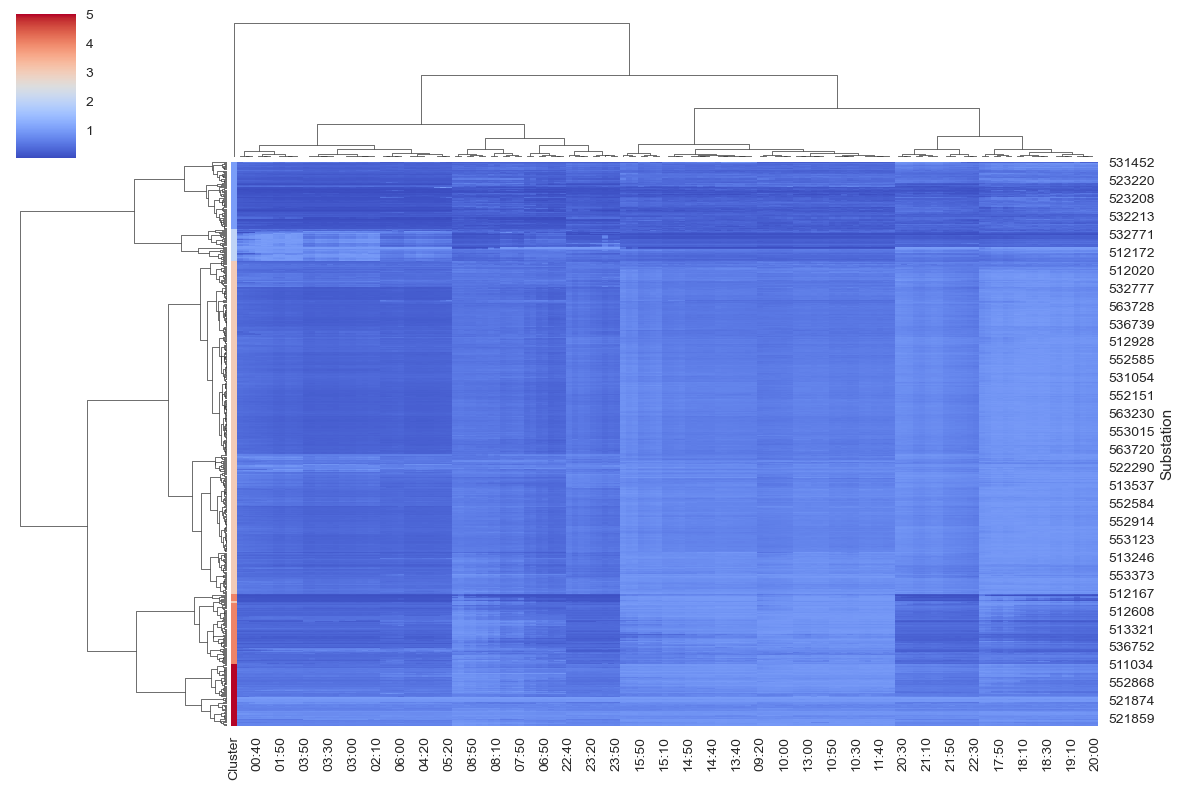

In [667]:
# Use seaborn clustermap
sns.clustermap(
    df_stations_avg, 
    metric='euclidean', 
    method='ward', 
    cmap='coolwarm', 
    figsize=(12, 8)
)
plt.show()

- (ii) Choice of the number of clusters and labeling of substations

In [687]:
from scipy.cluster.hierarchy import fcluster

# Choice of the threshold based on the dendrogram
threshold = 20  # Adjust this value based on the dendrogram visualization

# Assign cluster labels
cluster_labels = fcluster(linkage_matrix, t=threshold, criterion='distance')

# Add cluster labels to the original data
df_stations_avg['Cluster'] = cluster_labels

# Count the number of substations in each cluster
cluster_counts = df_stations_avg['Cluster'].value_counts()

# Display results
print("Cluster counts:",cluster_counts)


Cluster counts: Cluster
3    318
4     64
1     64
5     59
2     30
Name: count, dtype: int64


Based on the chosen threshold, five clusters are identified. Clusters 1, 2, 4, and 5 have fewer substations, with 64, 30, 64, and 59 in each group, respectively, compared to Cluster 3, which contains 318 substations.

- (iii) Daily average demand profiles visualisation

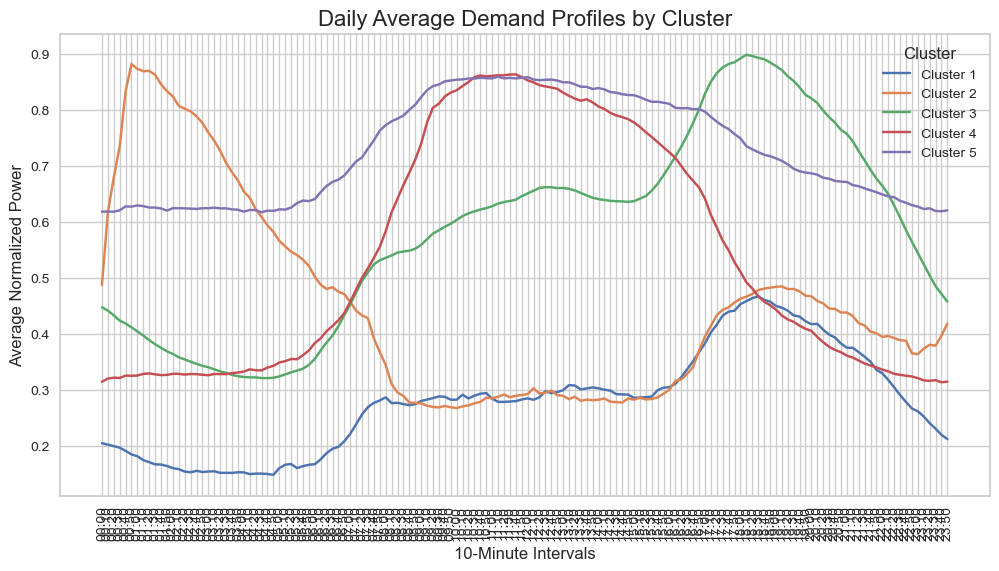

In [695]:
# Group data by cluster and calculate the mean daily demand profile
cluster_profiles = df_stations_avg.groupby('Cluster').mean()

# Transpose data for easier plotting (intervals as rows)
cluster_profiles_transposed = cluster_profiles.T

palette = sns.color_palette("deep", n_colors=cluster_profiles_transposed.columns.size)

# Plot each cluster's daily average demand profile
plt.figure(figsize=(12, 6))

for i, cluster in enumerate(cluster_profiles_transposed.columns):
    plt.plot(cluster_profiles_transposed.index, 
             cluster_profiles_transposed[cluster], 
             label=f'Cluster {cluster}', 
             color=palette[i])

# Customize the plot
plt.title('Daily Average Demand Profiles by Cluster', fontsize=16)
plt.xlabel('10-Minute Intervals', fontsize=12)
plt.ylabel('Average Normalized Power', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.legend(title='Cluster', fontsize=10)
plt.show()

The plot shows lines for each cluster, representing their average demand profiles across all 10-minute intervals in a day. Overall, each cluster reflects distinct patterns of daily activity, likely corresponding to the type of area serviced by the substation. Cluster has low power demand throughout the day. It starts at approximately 0.2 with minimal fluctuation indicating a steady usage pattern, possibly for substations serving industrial or non-residential areas with constant power needs. Meanwhile, Clusters 2 begins at approximatively 0.5 and peaks sharply early in the day at 0.88 and declines consistently. It likely represents areas where power demand is high in the morning and decreases as the day progresses.
In the same time, Cluster 3 begings with moderate demand in the morning, peaking mid-day at 0.9, and gradually tapering off in the evening suggesting a mixed-use of areas where both residential and commercial activities drive demand. Cluster 4 starts at approximatively 0.3 and gradually increases in power demand, peaking in the afternoon or early evening, and declining slowly. This could represent areas dominated by commercial activity or substations serving business districts. CLuster 5 starts at approximatively 0.62 with a consistent high power demand throughout the day.
This indicates areas with sustained power usage, such as large industrial zones or critical infrastructure.

## 3- Cluster evaluation

In [689]:
from sklearn.metrics import silhouette_samples, silhouette_score
# Perform clustering again to ensure consistency
clustering_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
cluster_labels = clustering_model.fit_predict(df_stations_avg)

# Compute the average silhouette score
silhouette_avg = silhouette_score(df_stations_avg, cluster_labels)
print(f"Average Silhouette Score: {silhouette_avg:.2f}")

Average Silhouette Score: 0.50


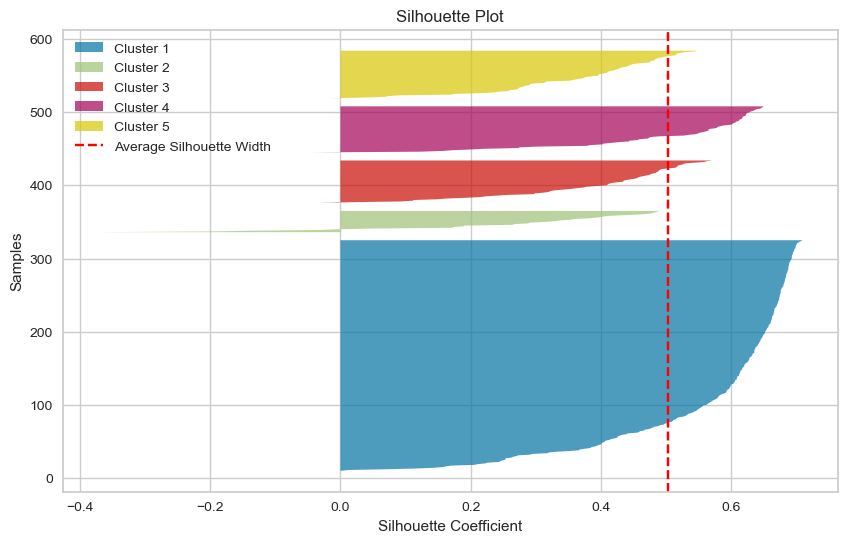

In [690]:
# Silhouette plot
n_clusters = len(np.unique(cluster_labels))
y_lower = 10

plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    # Aggregate silhouette scores for samples in the cluster
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()

    cluster_size = len(cluster_silhouette_vals)
    y_upper = y_lower + cluster_size

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7,
        label=f"Cluster {i+1}"
    )
    y_lower = y_upper + 10  # 10 for spacing

# Plot average silhouette score
plt.axvline(x=silhouette_avg, color="red", linestyle="--", label="Average Silhouette Width")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Samples")
plt.title("Silhouette Plot")
plt.legend()
plt.show()

## 4- Putting data back into context

The average silhouette score is 0.50, indicating that the substations are appropriately clustered. Cluster 1 is the largest cluster with high silhouette values, demonstrating good cohesion and separation. Cluster 2 is the smallest cluster, with moderate silhouette scores. Cluster 3 is a compact cluster with consistently high silhouette values, reflecting strong definition. Cluster 4 shows slight overlap or ambiguity, as evidenced by lower silhouette scores for some samples. Cluster 5 is a small cluster with silhouette values close to the average.

# Reference list

[1] ChatGPT.2024. Free version 1.1.0